In [1]:
%load_ext autoreload
%autoreload 2

In [14]:
import afterglowpy as grb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares
import pickle
import sys

from scipy.optimize import curve_fit
from astropy.time import Time

In [3]:
sys.path.append('/home/masson/afterglowpy')
from orphan_modules.tools import pseudo_obs_with_points, mag_to_flux, flux_to_mag
from orphan_modules.plotting_lc import plot_pseudo_obs

In [4]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

## Rescaling process: example of a light curve

First, the points are rescaled to the r-band. To do so, we use the fact that $F_\nu \propto \nu^{-\beta}$ where $\beta$ is the spectral index. In the slow cooling regime, $-\beta = -(p-1)/2$ (for $\nu_m < \nu < \nu_c$) or $-\beta = -p/2$ (for $\nu_c < \nu$) depending on the value of the observed frequency $\nu$.

In our case, we consider $p$ = 2.2 so $-\beta$ goes from- 1.1 to -0.6 (with a continuum of values between). As we don't know what is the value of $\beta$ at the time of the detection, we choose the use the value of $\beta$ that minimize the distance between the points of the most populated band (except the r-band of course) and the r-band points.

For the most populated band, we compute the rescaled flux in the r-band using 10 values of $-\beta$ between -1.1 and 0.6. We then compute the distance between the rescaled points and the true r-band points, and we choose the value of $\beta$ that minimize this distance. This value of $\beta$ is used for all the bands by doing:
$$ F_{\nu, rescaled} = F_\nu \times (\frac{\nu_r}{\nu})^{-\beta}$$
Where $F_{\nu, rescaled}$ is the flux in one band rescaled to the r-band, $F_\nu$ is the flux in one band that is not rescaled, $\nu_r$ is the mean frequency of the r-band and $\nu$ is the mean frequency of the considered band.

In [5]:
# import orphan population
file_open = open('/home/masson/afterglowpy/data/orphans_pseudo_obs_5pts_low_redshift.pkl', 'rb')
orphans = pickle.load(file_open)
file_open.close()

/home/masson/anaconda3/envs/afterglowpy/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


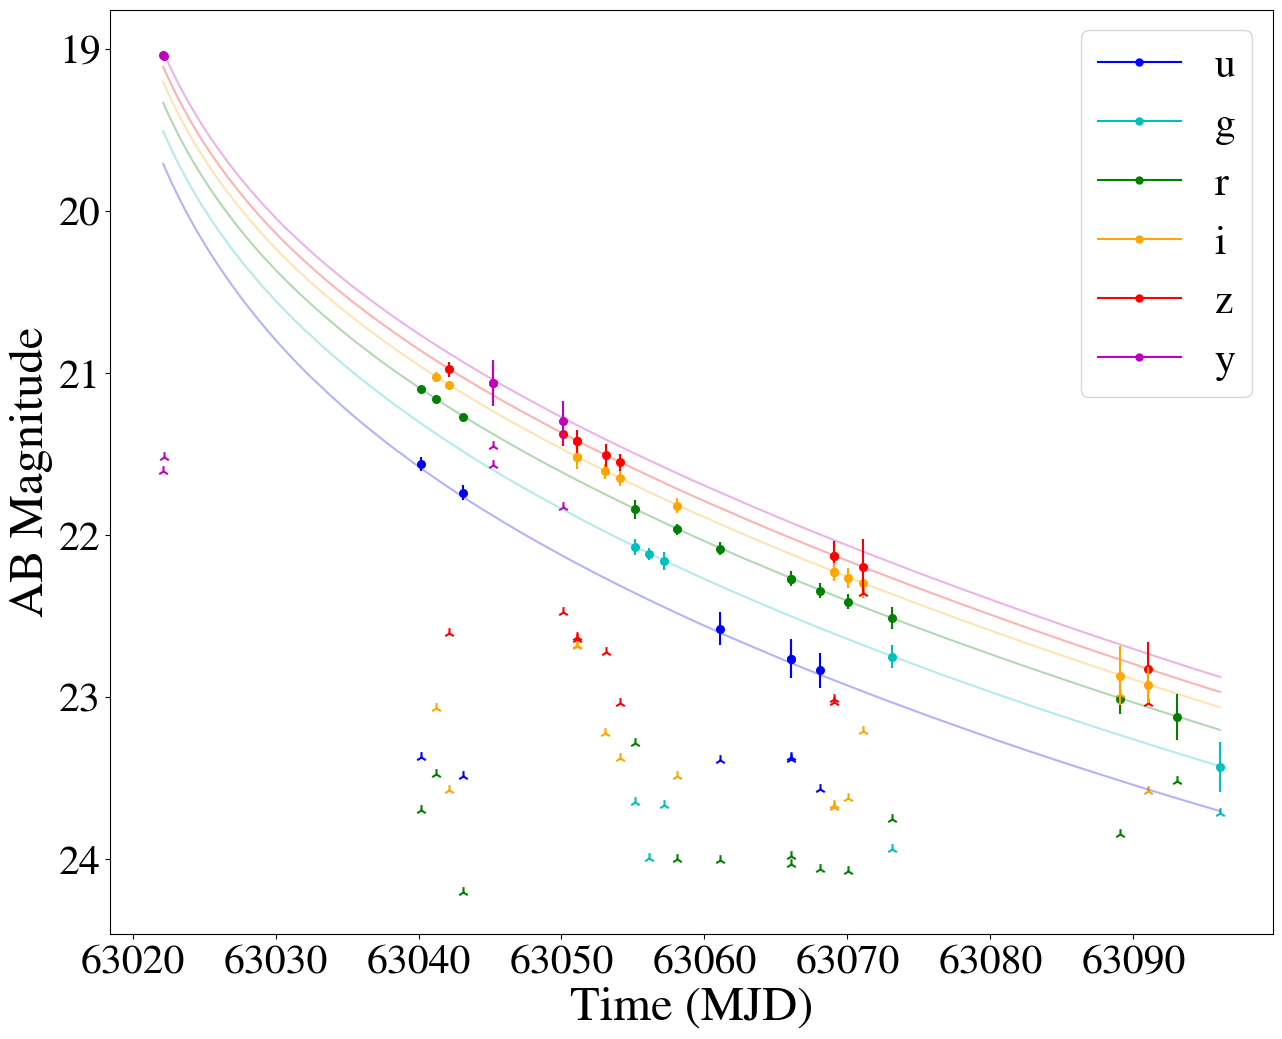

In [6]:
# STEP1 : CHOOSE ONE NICE ORPHAN
oa = orphans[48]
plot_pseudo_obs(oa, extinction=False)

In [7]:
# compute the flux of the considered light curve 
mags = np.array(oa['mags'])
flux = mag_to_flux(mags)

In [8]:
# STEP 2: SORT THE DATA BASED ON THEIR FILTER

# colors and mean frequency of the band u, g, r, i, z, y
colors = ['b', 'c', 'g', 'orange', 'r', 'm']
all_nu = [840336134453781.4, 629326620516047.8, 482703137570394.2, 397614314115308.1, 344530577088716.56, 
          298760145396604.1]

all_mags = []
all_flux = []
all_time = []
all_err = []

# sort the magnitudes, flux, times and errors based on their filter
for f in colors:
    
    all_mags.append([oa['mags'][j] for j in range(len(oa['mags'])) 
                     if oa['mags'][j] < oa['mags_lim'][j] and oa['filt'][j]==f])
    
    all_flux.append([flux[j] for j in range(len(flux)) 
                     if oa['mags'][j] < oa['mags_lim'][j] and oa['filt'][j]==f])
    
    all_time.append([oa['time'][j]-min(oa['time']) for j in range(len(oa['mags'])) 
            if oa['mags'][j] < oa['mags_lim'][j] and oa['filt'][j]==f])
    
    all_err.append([oa['mags_err'][j] for j in range(len(oa['mags'])) 
            if oa['mags'][j] < oa['mags_lim'][j] and oa['filt'][j]==f])

In [9]:
# STEP 3: CONSTRAIN BETA

# choose values of -beta between -(p-1)/2 and -p/2
beta = np.linspace(-0.6, -1.1, 10)

# use the most populated band to constrain beta
len_flux = np.array([len(x) if x != all_flux[2] else 0 for x in all_flux])
more_flux = all_flux[np.where(len_flux == max(len_flux))[0][0]]
more_flux_time = all_time[np.where(len_flux == max(len_flux))[0][0]]
more_flux_nu = all_nu[np.where(len_flux == max(len_flux))[0][0]]

d = []

for b in beta:
    
    # compute the rescaled flux for each beta
    all_flux_one_r = np.array(more_flux) * (all_nu[2] / more_flux_nu)**(b)
    
    # compute the euclidean distance between the rescaled flux and the true r-band flux 
    d.append(np.sum(np.sqrt((np.array(more_flux_time)[:, np.newaxis] - np.array(all_time[2])[np.newaxis, :])**2 + 
                     (all_flux_one_r[:, np.newaxis] - np.array(all_flux[2])[np.newaxis, :])**2)))

In [10]:
# STEP 4: RESCALE ALL THE BANDS WITH THE BEST BETA VALUE

all_flux_r = []

# for the beta that minimise the distance, rescale the flux for all the bands
for f, nu in zip(all_flux, all_nu):
    all_flux_r.append(np.array(f) * (all_nu[2] / nu)**(beta[np.where(d == min(d))])) 

In [11]:
# STEP 5: SORT ALL THE DATA TO CREATE ONE "TIME" ARRAY, ONE "FLUX" ARRAY AND ONE "ERROR" ARRAY

time = np.concatenate(all_time)
flux = np.concatenate(all_flux_r)
err = np.concatenate(all_err)
time_sorted = np.sort(time)
flux_sorted = np.array([f for _, f in sorted(zip(time, flux))])
mags_sorted = flux_to_mag(flux_sorted)
err_sorted = np.array([e for _, e in sorted(zip(time, err))])

(25.0, 17.5)

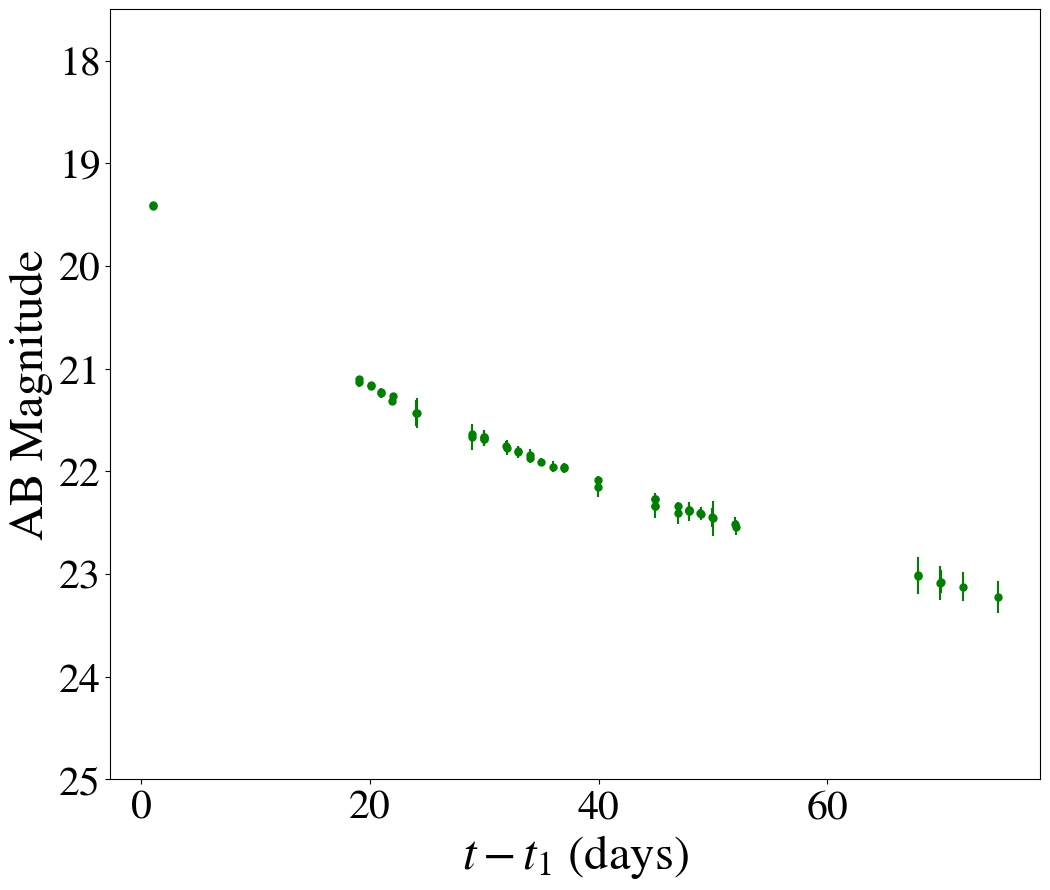

In [12]:
# STEP 6: PLOT THE RESCALED LIGHT CURVE

plt.rcParams.update({'font.size': 30})
plt.figure(figsize=(12,10))

t_fit = np.linspace(min(time_sorted)+1, max(time_sorted), num=100)
params = np.array([0.04, 20.25, -1.0, 0.02])

plt.errorbar(time_sorted+1, mags_sorted, yerr=err_sorted, marker='o', markersize=5, color='g', ls='')
#plt.plot(t_fit, model(t_fit, params))

plt.xlabel(r'$t - t_1$ (days)', fontsize=35)
plt.ylabel('AB Magnitude', fontsize=35)
plt.gca().invert_yaxis()
plt.ylim(25,17.5)
#plt.savefig('../figures/slides_pseudo_obs_example_rescaling.png', transparent=True, bbox_inches='tight')
#plt.savefig('../figures/slides_pseudo_obs_example_rescaling.pdf', transparent=True, bbox_inches='tight')

## Fit the light curves with `iminuit`

In [17]:
def model(t, params):
    """Function used to fit the light curve (determined using an MvSR algorithm, see Russeil et al. 2024)

    Parameters
    ----------
    t: list of float
        Concatenated time for the object
    params: tuple of float
        Parameters of the function, to estimate
    """

    A, B, C, D = params
    return A * t + B + C * np.exp(-D * t)

### Scan of the $\beta$ values

<ValueView A=0.024559120120623668 B=21.169345422111178 C=-3.48438681839707 D=0.05250884166562677>
<ValueView A=0.029466308510555983 B=20.77268431884545 C=-3.320964700852528 D=0.06933804535282234>
<ValueView A=0.032282868708365164 B=20.568685245514644 C=-3.4917560882322505 D=0.08934042592976837>
<ValueView A=0.03378920754565318 B=20.472831775768498 C=-3.974080044748007 D=0.11239220676296502>
<ValueView A=0.03446769050954135 B=20.440184145617877 C=-4.741689270578718 D=0.13674345906203325>
<ValueView A=0.03461556674088584 B=20.43779226649275 C=-5.213906775888972 D=0.14875281724992168>


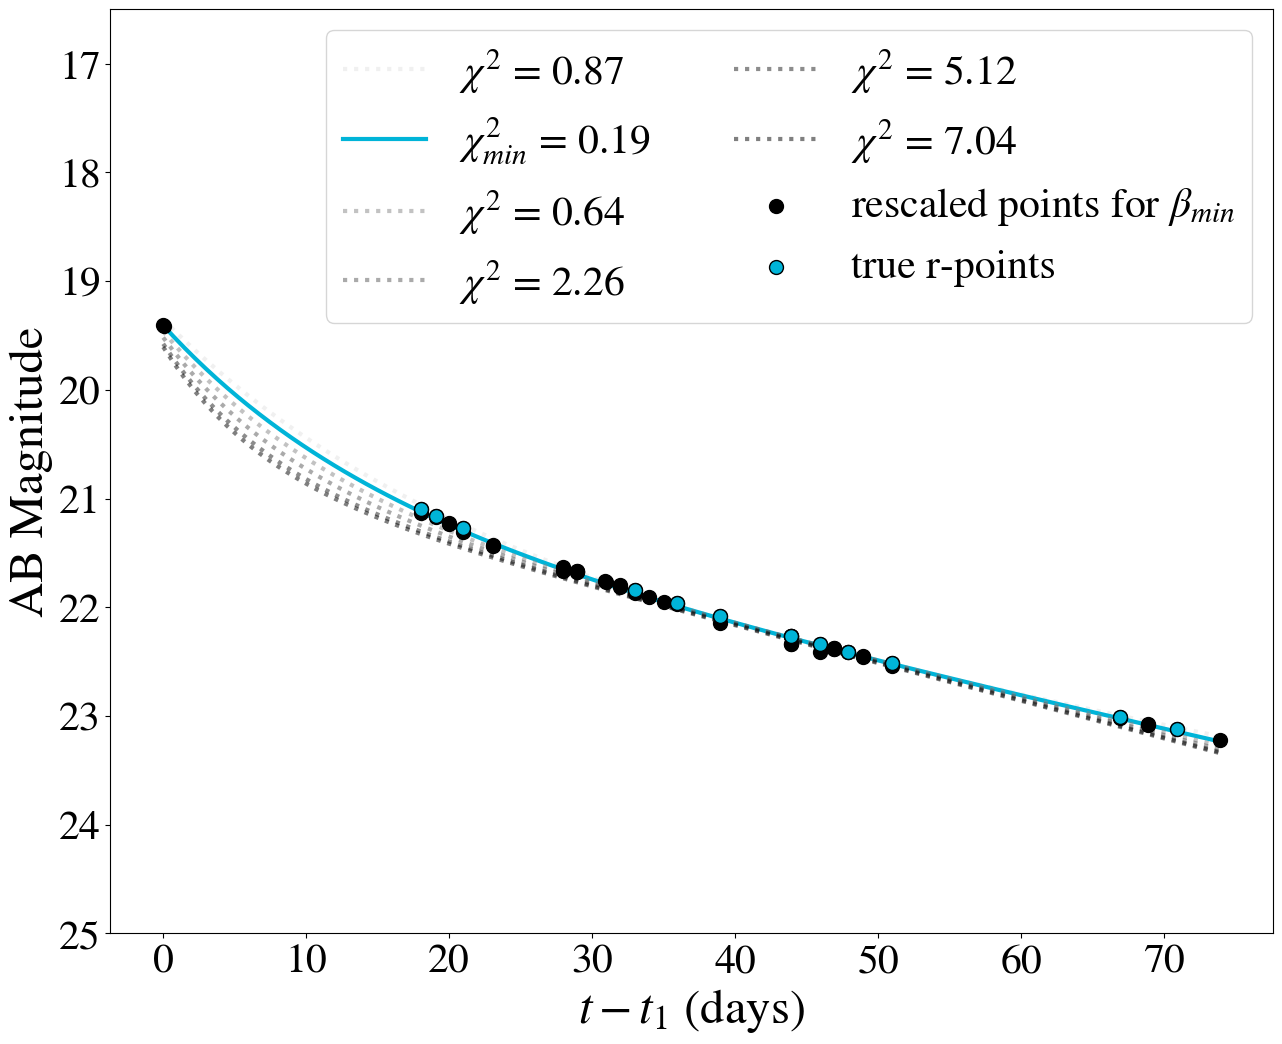

In [18]:
mags_sorted = []
err = []

for b in beta:
    all_flux_r = []
    
    # for the beta that minimize the distance, rescale the flux for all the bands
    for f, nu in zip(all_flux, all_nu):
        #if nu != 840336134453781.4 and nu!=397614314115308.1 and nu!= 344530577088716.56:   #20
        #if nu != 840336134453781.4:   #689
        #all_flux_r.append(np.array(f) * (all_nu[2] / nu)**(-p/2))
        all_flux_r.append(np.array(f) * (all_nu[2] / nu)**b) 

    # sorting them to create one array with all the times and one with all the fluxes
    time = np.concatenate(all_time)
    flux = np.concatenate(all_flux_r)
    err.append(np.concatenate(all_err))
    time_sorted = np.sort(time)
    flux_sorted = np.array([f for _, f in sorted(zip(time, flux))])
    mags_sorted.append(flux_to_mag(flux_sorted))


plt.rcParams.update({'font.size': 30})
plt.figure(figsize=(15,12))

colors = plt.cm.Greys(np.linspace(0.2,1.,10))
chi2_list = []

for i in range(10):
    
    if i%2 == 0 or i==9:
    
        # data used for the fit
        t = time_sorted + 10
        y = mags_sorted[i]
        yerr = err[i]

        least_squares = LeastSquares(t, y, yerr, model)

        initial = np.array([0.03, 22.25, -1.04, 0.08])
        m = Minuit(least_squares, initial, name=('A', 'B', 'C', 'D'))

        m.limits = [(-1e4, 1e4), (-1e6, 1e6), (-1e7, 1e7), (-0.03, 10.)]

        m.migrad()  # finds minimum of least_squares function
        m.hesse()  # accurately computes uncertainties

        A = m.values[0]
        B = m.values[1]
        C = m.values[2]
        D = m.values[3]
        
        print(m.values)

        chi2 = m.fmin.reduced_chi2
        
        t_fit = np.linspace(min(t), max(t), 100)

        # parameters of the max ln likelihood
        best_fit_model = model(t_fit, (A, B, C, D))

        if beta[i] != beta[np.where(d == min(d))]:
            plt.plot(t_fit-10, best_fit_model, color=colors[i], ls=':', lw=3, alpha=0.5, label=r'$\chi^2$ = %.2f' %chi2, zorder=1)


        else: 
            plt.plot(t_fit-10, best_fit_model, color='#00b4d8', lw=3, label=r'$\chi^2_{min}$ = %.2f' %chi2, zorder=1)

    else:
        chi2_list.append(np.nan)
        
for i in range(10):
    if beta[i] == beta[np.where(d == min(d))]:
        plt.scatter(time_sorted, mags_sorted[i], color='k', marker='o', s=100, label=r'rescaled points for $\beta_{min}$', zorder=2)

plt.scatter(np.array(all_time[2]), all_mags[2], marker='o', s=100, edgecolor='k', facecolor='#00b4d8', label='true r-points', zorder=2)

plt.xlabel('$t-t_1$ (days)', fontsize=35)
plt.ylabel('AB Magnitude', fontsize=35)
plt.gca().invert_yaxis()
plt.ylim(25,16.5)

plt.legend(fontsize=30, ncol=2)

#plt.savefig('../figures/fit_beta_scan.pdf', format="pdf", bbox_inches="tight", transparent=True)

plt.show()

### Do the fit

<ValueView A=0.03389255735253993 B=20.537580716705577 C=-3.0671599880834037 D=0.07373145429937168>


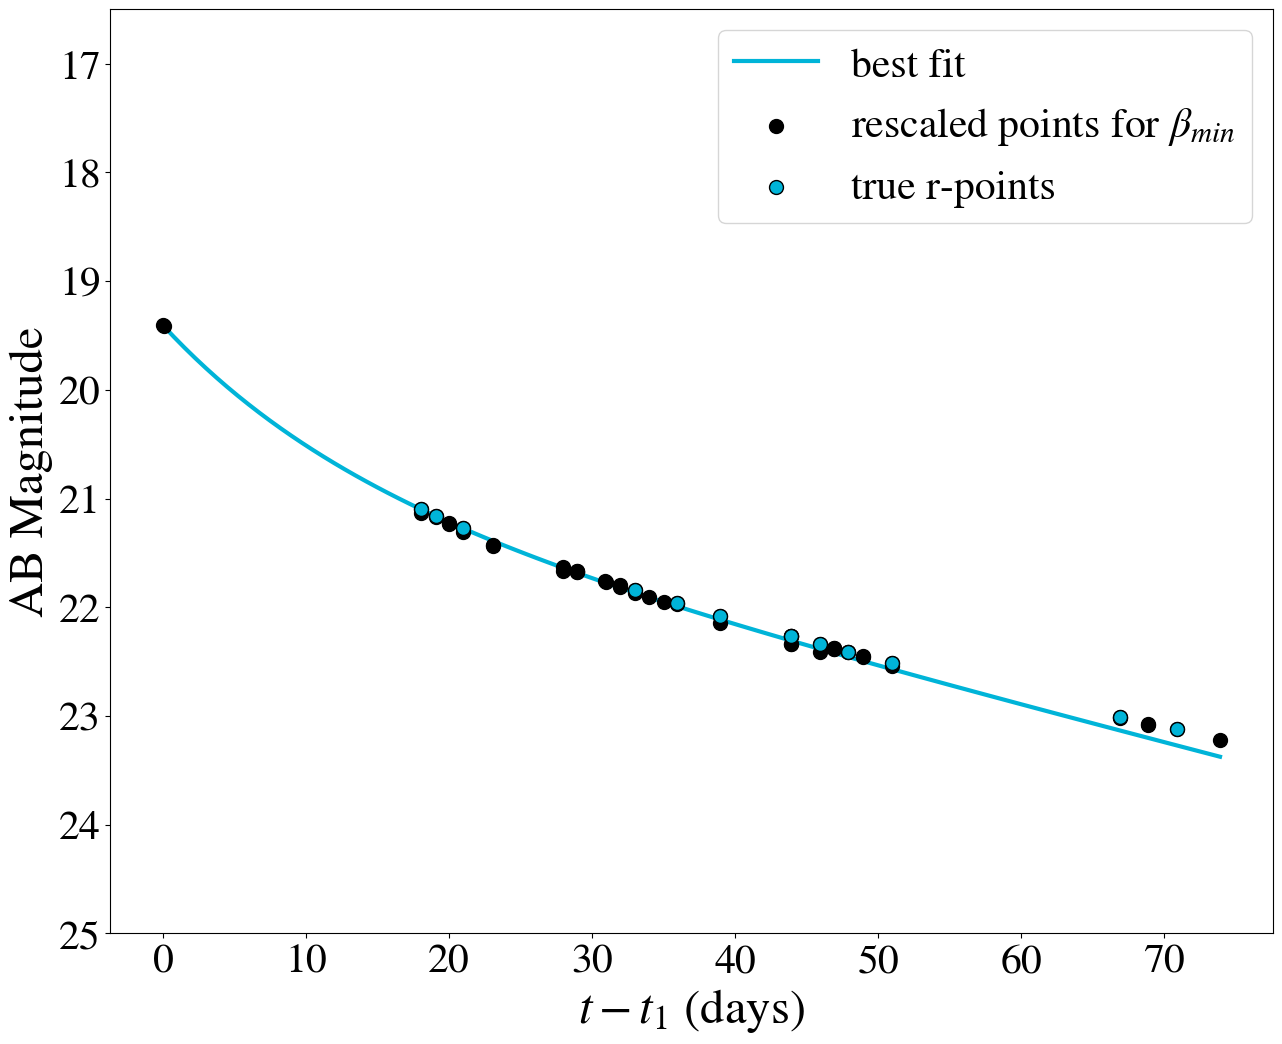

In [42]:
mags_sorted = []
err = []

for b in beta:
    all_flux_r = []
    
    # for the beta that minimize the distance, rescale the flux for all the bands
    for f, nu in zip(all_flux, all_nu):
        all_flux_r.append(np.array(f) * (all_nu[2] / nu)**(beta[np.where(d == min(d))])) 

# sorting them to create one array with all the times and one with all the fluxes

time = np.concatenate(all_time)
flux = np.concatenate(all_flux_r)
err = np.concatenate(all_err)

# sort everything by time
time_sorted = np.sort(time)
flux_sorted = np.array([f for _, f in sorted(zip(time, flux))])
flux_err_sorted = np.array([e for _, e in sorted(zip(time, err))])
mags_sorted = flux_to_mag(flux_sorted)
mags_err_sorted = (2.5 / np.log(10)) * (flux_err_sorted / flux_sorted)


plt.rcParams.update({'font.size': 30})
plt.figure(figsize=(15,12))

colors = plt.cm.Greys(np.linspace(0.2,1.,10))
    
# data used for the fit
t = time_sorted + 10
y = mags_sorted
yerr = mags_err_sorted

least_squares = LeastSquares(t, y, yerr, model)

initial = np.array([0.0, 22., -1., 0.01])
m = Minuit(least_squares, initial, name=('A', 'B', 'C', 'D'))

m.limits = [(-1e4, 1e4), (-1e6, 1e6), (-1e7, 1e7), (-0.03, 10.)]

m.migrad()  # finds minimum of least_squares function
m.hesse()  # accurately computes uncertainties

A = m.values[0]
B = m.values[1]
C = m.values[2]
D = m.values[3]

print(m.values)

chi2 = m.fmin.reduced_chi2

t_fit = np.linspace(min(t), max(t), 100)

# parameters of the max ln likelihood
best_fit_model = model(t_fit, (A, B, C, D))

plt.plot(t_fit-10, best_fit_model, color='#00b4d8', lw=3, label='best fit')
        
for i in range(10):
    if beta[i] == beta[np.where(d == min(d))]:
        plt.scatter(time_sorted, mags_sorted, color='k', marker='o', s=100, label=r'rescaled points for $\beta_{min}$', zorder=2)

plt.scatter(np.array(all_time[2]), all_mags[2], marker='o', s=100, edgecolor='k', facecolor='#00b4d8', label='true r-points', zorder=2)

plt.xlabel('$t-t_1$ (days)', fontsize=35)
plt.ylabel('AB Magnitude', fontsize=35)
plt.gca().invert_yaxis()
plt.ylim(25,16.5)

plt.legend(fontsize=30)

#plt.savefig('../figures/fit_beta_scan.pdf', format="pdf", bbox_inches="tight", transparent=True)

plt.show()